# ♻️ EcoScan — Garbage Detection (MobileNetV2 + Fine-Tuning)

**Classes:** cardboard | glass | metal | paper | plastic | trash  
**Architecture:** MobileNetV2 (ImageNet pretrained) + custom head  
**Strategy:** Phase 1 → train head only | Phase 2 → fine-tune backbone  

---
### 📁 Expected Dataset Structure
```
dataset-resized/
    TRAIN/
        cardboard/
        glass/
        metal/
        paper/
        plastic/
        trash/
    TEST/
        cardboard/
        glass/
        ...
```

## Cell 1 — Install Dependencies

In [1]:
# Run this only once — skip if already installed
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "tensorflow>=2.13.0", "Pillow", "numpy", "matplotlib",
    "scikit-learn", "seaborn", "--quiet"])
print("✅ All packages ready")


✅ All packages ready


## Cell 2 — Imports

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.21.0
GPU available      : False


## Cell 3 — Configuration  
⚙️ **Only change paths here — rest of notebook runs automatically**

In [3]:
# ── CHANGE THESE PATHS TO MATCH YOUR MACHINE ──────────────────────────────────
TRAIN_DIR = r"D:\module 8 project\dataset-resized\TRAIN"
TEST_DIR  = r"D:\module 8 project\dataset-resized\TEST"
MODEL_SAVE_PATH = r"D:\PROJECTS AIPA\MINI PROJECTS\module 8 mini\garbage detection\ecoscan_best_model.h5"

# ── TRAINING SETTINGS ─────────────────────────────────────────────────────────
CLASSES    = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# Phase 1 = train only the head (fast)
# Phase 2 = fine-tune backbone (slower, more accurate)
PHASE1_EPOCHS = 10   # head training
PHASE2_EPOCHS = 30   # fine-tuning  (total = 40 epochs)

VAL_SPLIT  = 0.2     # 20% of TRAIN used for validation

# ── VERIFY PATHS ──────────────────────────────────────────────────────────────
print("Checking paths...")
for label, path in [("TRAIN", TRAIN_DIR), ("TEST", TEST_DIR)]:
    if os.path.isdir(path):
        classes_found = [c for c in CLASSES if os.path.isdir(os.path.join(path, c))]
        total_imgs = sum(
            len(os.listdir(os.path.join(path, c)))
            for c in classes_found
        )
        print(f"  ✅ {label}: {len(classes_found)} classes | {total_imgs} images")
    else:
        print(f"  ❌ {label} NOT FOUND: {path}")
        print("      → Fix the path above and re-run this cell")

Checking paths...
  ✅ TRAIN: 6 classes | 2527 images
  ✅ TEST: 6 classes | 2527 images


## Cell 4 — Dataset Exploration (Class Balance Check)

Class           Train     Test
------------------------------
  cardboard       403      403
  glass           501      501
  metal           410      410
  paper           594      594
  plastic         482      482
  trash           137      137
------------------------------
  TOTAL          2527     2527


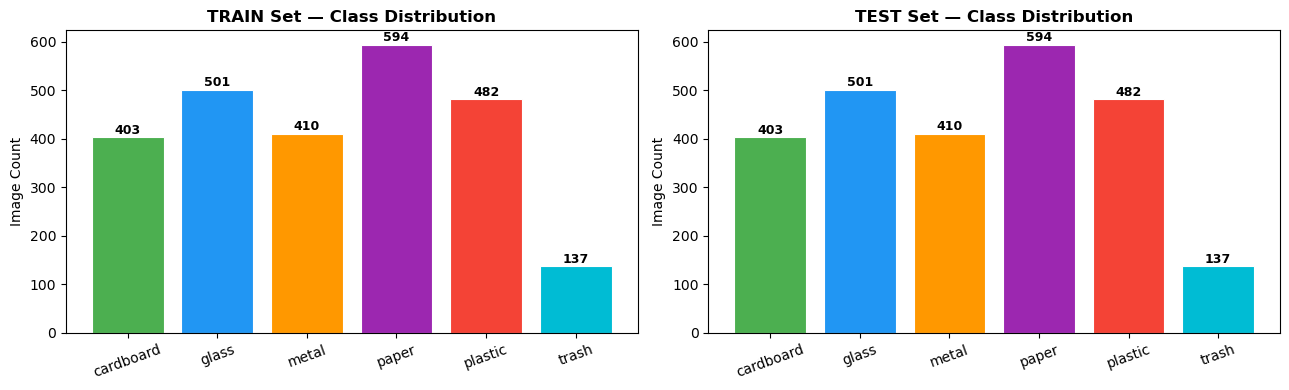

📊 Class distribution saved as class_distribution.png


In [4]:
def count_images(base_dir, classes):
    counts = {}
    for c in classes:
        folder = os.path.join(base_dir, c)
        if os.path.isdir(folder):
            imgs = [f for f in os.listdir(folder)
                    if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))]
            counts[c] = len(imgs)
        else:
            counts[c] = 0
    return counts

train_counts = count_images(TRAIN_DIR, CLASSES)
test_counts  = count_images(TEST_DIR,  CLASSES)

print(f"{'Class':<12} {'Train':>8} {'Test':>8}")
print("-" * 30)
for c in CLASSES:
    print(f"  {c:<10} {train_counts[c]:>8} {test_counts[c]:>8}")
print("-" * 30)
print(f"  {'TOTAL':<10} {sum(train_counts.values()):>8} {sum(test_counts.values()):>8}")

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336','#00BCD4']

for ax, (counts, title) in zip(axes, [(train_counts,'TRAIN'),(test_counts,'TEST')]):
    bars = ax.bar(counts.keys(), counts.values(), color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(f'{title} Set — Class Distribution', fontweight='bold', fontsize=12)
    ax.set_ylabel('Image Count')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("📊 Class distribution saved as class_distribution.png")

## Cell 5 — Data Generators with Augmentation

In [5]:
# Training generator — heavy augmentation to prevent overfitting
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.25,
    horizontal_flip=True,
    brightness_range=[0.75, 1.25],
    channel_shift_range=20,
    fill_mode='nearest',
    validation_split=VAL_SPLIT
)

# Test generator — NO augmentation, only rescale
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    subset='validation',
    shuffle=False,
    seed=42
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=False
)

print(f"\n📦 Train samples      : {train_gen.samples}")
print(f"📦 Validation samples : {val_gen.samples}")
print(f"📦 Test samples       : {test_gen.samples}")
print(f"\nClass indices: {train_gen.class_indices}")

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Found 2527 images belonging to 6 classes.

📦 Train samples      : 2024
📦 Validation samples : 503
📦 Test samples       : 2527

Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


## Cell 6 — Sample Augmented Images (Visual Check)

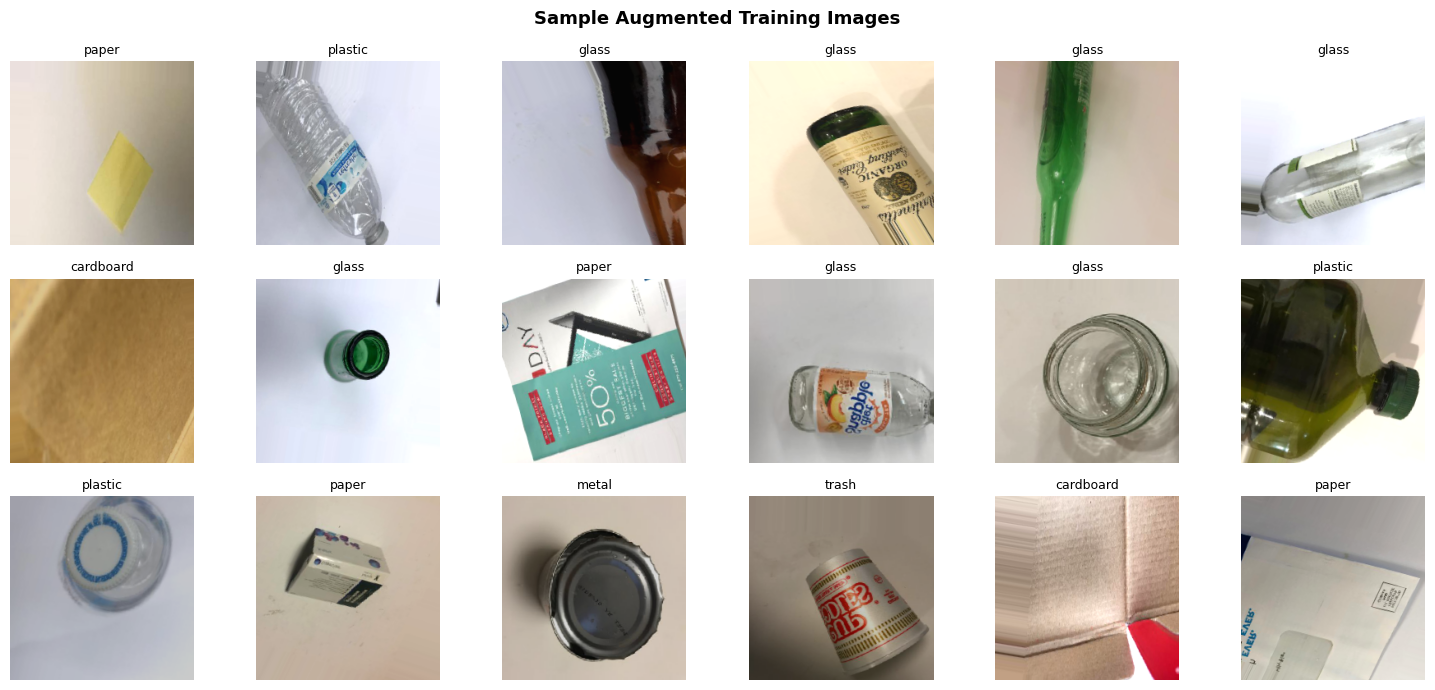

In [6]:
# Show one sample batch from the training generator
batch_images, batch_labels = next(train_gen)
class_names = list(train_gen.class_indices.keys())

fig, axes = plt.subplots(3, 6, figsize=(15, 7))
for i, ax in enumerate(axes.flat):
    if i < len(batch_images):
        ax.imshow(batch_images[i])
        ax.set_title(class_names[np.argmax(batch_labels[i])], fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Augmented Training Images', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('sample_augmented.png', dpi=100, bbox_inches='tight')
plt.show()

## Cell 7 — Build Model (MobileNetV2 + Custom Head)

In [7]:
def build_model(num_classes=6):
    base = MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False  # frozen for Phase 1

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.45)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name='EcoScan_MobileNetV2')

model = build_model(num_classes=len(CLASSES))

# Print model summary (only top layers)
trainable     = np.sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])
print(f"\nModel : {model.name}")
print(f"Trainable params     : {trainable:,}")
print(f"Non-trainable params : {non_trainable:,}")
print(f"Total params         : {trainable + non_trainable:,}")


Model : EcoScan_MobileNetV2
Trainable params     : 791,302
Non-trainable params : 2,260,544
Total params         : 3,051,846


## Cell 8 — Phase 1: Train Classification Head

In [8]:
print("="*55)
print("  🚀 PHASE 1 — Training classification head only")
print(f"     Epochs: {PHASE1_EPOCHS} | LR: 1e-3")
print("="*55)

callbacks_p1 = [
    ModelCheckpoint(
        MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_p1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=PHASE1_EPOCHS,
    callbacks=callbacks_p1
)

print(f"\n✅ Phase 1 complete. Best val_accuracy: "
      f"{max(history_p1.history['val_accuracy'])*100:.2f}%")

  🚀 PHASE 1 — Training classification head only
     Epochs: 10 | LR: 1e-3
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.5399 - loss: 1.4816
Epoch 1: val_accuracy improved from None to 0.69583, saving model to D:\PROJECTS AIPA\MINI PROJECTS\module 8 mini\garbage detection\ecoscan_best_model.h5



Epoch 1: finished saving model to D:\PROJECTS AIPA\MINI PROJECTS\module 8 mini\garbage detection\ecoscan_best_model.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.6462 - loss: 1.1622 - val_accuracy: 0.6958 - val_loss: 0.9230 - learning_rate: 0.0010
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 745ms/step - accuracy: 0.7632 - loss: 0.7856
Epoch 2: val_accuracy improved from 0.69583 to 0.71571, saving model to D:\PROJECTS AIPA\MINI PROJECTS\module 8 mini\garbage detection\ecoscan_best_model.h5



Epoch 2: finished saving model to D:\PROJECTS AIPA\MINI PROJECTS\module 8 mini\garbage detection\ecoscan_best_model.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 935ms/step - accuracy: 0.7559 - loss: 0.8099 - val_accuracy: 0.7157 - val_loss: 0.8711 - learning_rate: 0.0010
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.7744 - loss: 0.7386
Epoch 3: val_accuracy improved from 0.71571 to 0.72763, saving model to D:\PROJECTS AIPA\MINI PROJECTS\module 8 mini\garbage detection\ecoscan_best_model.h5



Epoch 3: finished saving model to D:\PROJECTS AIPA\MINI PROJECTS\module 8 mini\garbage detection\ecoscan_best_model.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 937ms/step - accuracy: 0.7796 - loss: 0.7326 - val_accuracy: 0.7276 - val_loss: 0.8217 - learning_rate: 0.0010
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 745ms/step - accuracy: 0.8212 - loss: 0.6480
Epoch 4: val_accuracy improved from 0.72763 to 0.74354, saving model to D:\PROJECTS AIPA\MINI PROJECTS\module 8 mini\garbage detection\ecoscan_best_model.h5



Epoch 4: finished saving model to D:\PROJECTS AIPA\MINI PROJECTS\module 8 mini\garbage detection\ecoscan_best_model.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 937ms/step - accuracy: 0.8226 - loss: 0.6171 - val_accuracy: 0.7435 - val_loss: 0.8302 - learning_rate: 0.0010
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.8241 - loss: 0.5726
Epoch 5: val_accuracy did not improve from 0.74354

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 940ms/step - accuracy: 0.8325 - loss: 0.5724 - val_accuracy: 0.7296 - val_loss: 0.8382 - learning_rate: 0.0010
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.8487 - loss: 0.5728
Epoch 6: val_accuracy improved from 0.74354 to 0.77336, saving model to D:\PROJECTS AIPA\MINI PROJECTS\module 8 mini\garbage detection\ecoscan_best_model.h5



Epoch 6: finished saving model to D:\PROJECTS AIPA\MINI PROJECTS\module 8 mini\garbage detection\ecoscan_best_model.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 945ms/step - accuracy: 0.8597 - loss: 0.5227 - val_accuracy: 0.7734 - val_loss: 0.7355 - learning_rate: 5.0000e-04
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.8670 - loss: 0.4769
Epoch 7: val_accuracy did not improve from 0.77336
64/64 ━━━━━━━━━━━━━━━━━━━━ 61s 955ms/step - accuracy: 0.8636 - loss: 0.4908 - val_accuracy: 0.7714 - val_loss: 0.7211 - learning_rate: 5.0000e-04
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.8832 - loss: 0.4527
Epoch 8: val_accuracy did not improve from 0.77336
64/64 ━━━━━━━━━━━━━━━━━━━━ 61s 952ms/step - accuracy: 0.8790 - loss: 0.4706 - val_accuracy: 0.7594 - val_loss: 0.8110 - learning_rate: 5.0000e-04
Epoch 9/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 757ms/step - accuracy: 0.8888 - loss: 0.4382
Epoch 9: val_accuracy did not improve from 0.77336

Epoch 9: ReduceLROnPlateau red

## Cell 9 — Phase 2: Fine-Tune Backbone (Last 40 Layers)

In [9]:
print("="*55)
print("  🔧 PHASE 2 — Fine-tuning backbone (last 40 layers)")
print(f"     Epochs: {PHASE2_EPOCHS} | LR: 1e-5 (low to preserve weights)")
print("="*55)

# Unfreeze last 40 layers of MobileNetV2
base_model = model.layers[1]  # MobileNetV2 is layer index 1
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

unfrozen = sum(1 for l in base_model.layers if l.trainable)
print(f"\nUnfrozen backbone layers: {unfrozen}")

callbacks_p2 = [
    ModelCheckpoint(
        MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-8,
        verbose=1
    )
]

# Lower LR is critical for fine-tuning — avoids destroying pretrained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_p2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=PHASE2_EPOCHS,
    callbacks=callbacks_p2
)

print(f"\n✅ Phase 2 complete. Best val_accuracy: "
      f"{max(history_p2.history['val_accuracy'])*100:.2f}%")

  🔧 PHASE 2 — Fine-tuning backbone (last 40 layers)
     Epochs: 30 | LR: 1e-5 (low to preserve weights)

Unfrozen backbone layers: 40
Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 889ms/step - accuracy: 0.7502 - loss: 0.8362
Epoch 1: val_accuracy improved from None to 0.75746, saving model to D:\PROJECTS AIPA\MINI PROJECTS\module 8 mini\garbage detection\ecoscan_best_model.h5



Epoch 1: finished saving model to D:\PROJECTS AIPA\MINI PROJECTS\module 8 mini\garbage detection\ecoscan_best_model.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.7648 - loss: 0.7938 - val_accuracy: 0.7575 - val_loss: 0.8720 - learning_rate: 1.0000e-05
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 893ms/step - accuracy: 0.7745 - loss: 0.7683
Epoch 2: val_accuracy did not improve from 0.75746
64/64 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.7861 - loss: 0.7303 - val_accuracy: 0.7217 - val_loss: 1.0034 - learning_rate: 1.0000e-05
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 929ms/step - accuracy: 0.8286 - loss: 0.6433
Epoch 3: val_accuracy did not improve from 0.75746
64/64 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.8157 - loss: 0.6589 - val_accuracy: 0.7038 - val_loss: 1.0376 - learning_rate: 1.0000e-05
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 889ms/step - accuracy: 0.8315 - loss: 0.5978
Epoch 4: val_accuracy did not improve from 0.75746

Epoch 4: ReduceLROnPlateau reducing lea

## Cell 10 — Plot Training History (Both Phases)

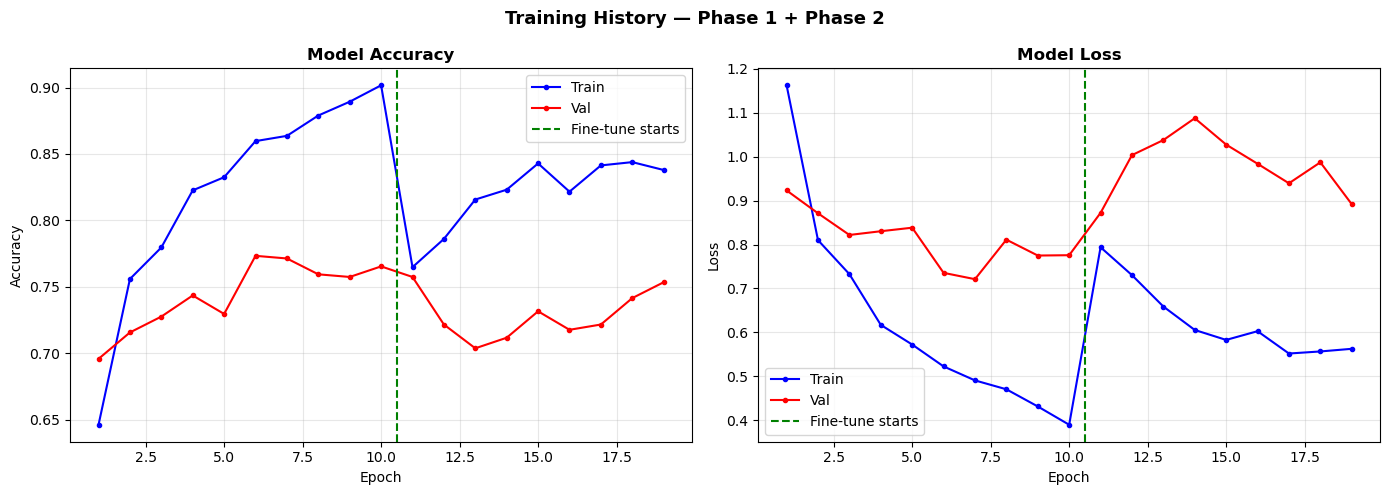


Final Train Accuracy     : 83.79%
Final Val   Accuracy     : 75.35%
Best  Val   Accuracy     : 77.34%


In [10]:
# Combine histories
def combine_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

acc     = combine_history(history_p1, history_p2, 'accuracy')
val_acc = combine_history(history_p1, history_p2, 'val_accuracy')
loss    = combine_history(history_p1, history_p2, 'loss')
val_loss= combine_history(history_p1, history_p2, 'val_loss')
epochs  = range(1, len(acc) + 1)
p1_end  = PHASE1_EPOCHS

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (train_vals, val_vals, title, ylabel) in zip(
    axes,
    [
        (acc,  val_acc,  'Model Accuracy',  'Accuracy'),
        (loss, val_loss, 'Model Loss',      'Loss')
    ]
):
    ax.plot(epochs, train_vals, 'b-o', markersize=3, label='Train', linewidth=1.5)
    ax.plot(epochs, val_vals,   'r-o', markersize=3, label='Val',   linewidth=1.5)
    ax.axvline(x=p1_end + 0.5, color='green', linestyle='--', linewidth=1.5,
               label='Fine-tune starts')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training History — Phase 1 + Phase 2', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('training_history.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nFinal Train Accuracy     : {acc[-1]*100:.2f}%")
print(f"Final Val   Accuracy     : {val_acc[-1]*100:.2f}%")
print(f"Best  Val   Accuracy     : {max(val_acc)*100:.2f}%")

## Cell 11 — Evaluate on Test Set

In [11]:
print("📊 Evaluating on TEST set...\n")
test_gen.reset()
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"\n🎯 Test Loss     : {test_loss:.4f}")
print(f"🎯 Test Accuracy : {test_acc*100:.2f}%")

📊 Evaluating on TEST set...

79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 346ms/step - accuracy: 0.8987 - loss: 0.3967

🎯 Test Loss     : 0.3967
🎯 Test Accuracy : 89.87%


## Cell 12 — Confusion Matrix + Classification Report

79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 362ms/step


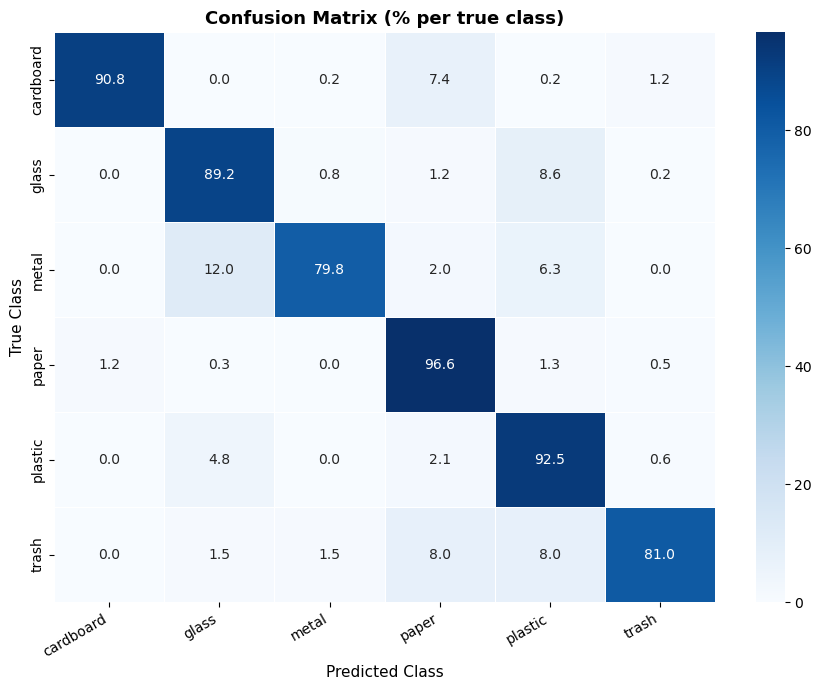


📋 Classification Report:
              precision    recall  f1-score   support

   cardboard       0.98      0.91      0.94       403
       glass       0.85      0.89      0.87       501
       metal       0.98      0.80      0.88       410
       paper       0.90      0.97      0.93       594
     plastic       0.83      0.93      0.88       482
       trash       0.90      0.81      0.85       137

    accuracy                           0.90      2527
   macro avg       0.91      0.88      0.89      2527
weighted avg       0.90      0.90      0.90      2527



In [12]:
# Get predictions
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # percentage

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm_pct, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=CLASSES, yticklabels=CLASSES,
    linewidths=0.5, ax=ax
)
ax.set_title('Confusion Matrix (% per true class)', fontweight='bold', fontsize=13)
ax.set_xlabel('Predicted Class', fontsize=11)
ax.set_ylabel('True Class', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# Per-class report
print("\n📋 Classification Report:")
print("="*60)
print(classification_report(y_true, y_pred, target_names=CLASSES))

## Cell 13 — Per-Class Accuracy Bar Chart

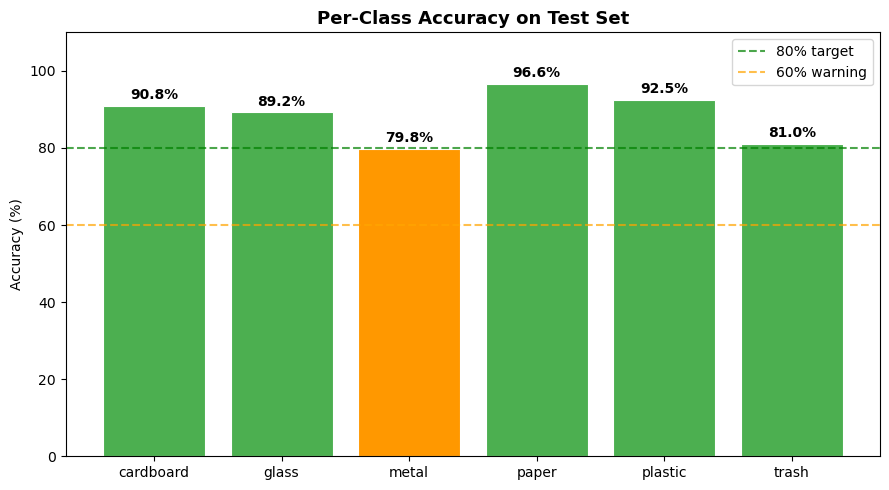


📊 Per-class accuracy:
  ✅  cardboard    : 90.8%
  ✅  glass        : 89.2%
  ⚠️  metal        : 79.8%
  ✅  paper        : 96.6%
  ✅  plastic      : 92.5%
  ✅  trash        : 81.0%


In [13]:
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ['#4CAF50' if a >= 80 else '#FF9800' if a >= 60 else '#F44336'
               for a in per_class_acc]
bars = ax.bar(CLASSES, per_class_acc, color=colors_bar, edgecolor='white', linewidth=0.8)
ax.axhline(y=80, color='green',  linestyle='--', alpha=0.7, label='80% target')
ax.axhline(y=60, color='orange', linestyle='--', alpha=0.7, label='60% warning')
ax.set_ylim(0, 110)
ax.set_title('Per-Class Accuracy on Test Set', fontweight='bold', fontsize=13)
ax.set_ylabel('Accuracy (%)')
ax.legend()

for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n📊 Per-class accuracy:")
for cls, acc_val in zip(CLASSES, per_class_acc):
    status = '✅' if acc_val >= 80 else ('⚠️' if acc_val >= 60 else '❌')
    print(f"  {status}  {cls:<12} : {acc_val:.1f}%")

## Cell 14 — Predict a Single Image
Change the image path below to test any image.

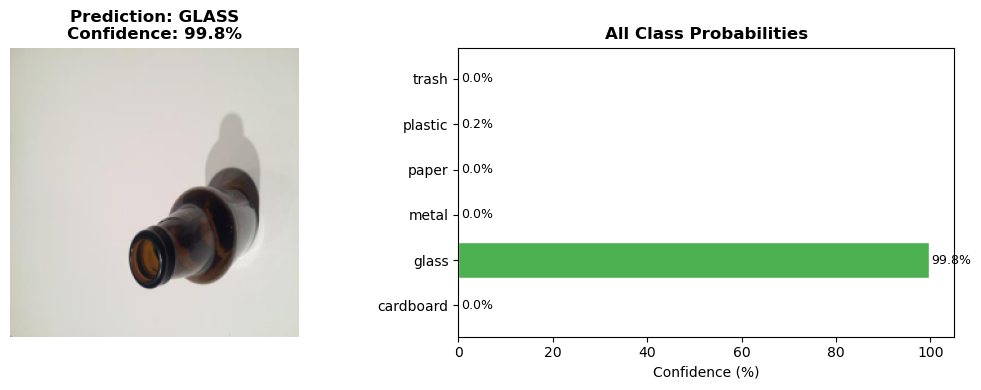


Result → Class: GLASS | Confidence: 99.8%


In [14]:
def predict_image(img_path, model, class_names, img_size=(224, 224)):
    """Predict the class of a single image and show confidence scores."""
    img = Image.open(img_path).convert('RGB').resize(img_size)
    arr = np.array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    probs = model.predict(arr, verbose=0)[0]
    pred_idx  = np.argmax(probs)
    pred_class = class_names[pred_idx]
    confidence = probs[pred_idx] * 100

    # Display
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

    ax1.imshow(img)
    ax1.set_title(f'Prediction: {pred_class.upper()}\nConfidence: {confidence:.1f}%',
                  fontweight='bold', fontsize=12)
    ax1.axis('off')

    colors_pred = ['#4CAF50' if i == pred_idx else '#90A4AE' for i in range(len(class_names))]
    ax2.barh(class_names, probs * 100, color=colors_pred, edgecolor='white')
    ax2.set_xlabel('Confidence (%)')
    ax2.set_title('All Class Probabilities', fontweight='bold')
    ax2.set_xlim(0, 105)
    for i, v in enumerate(probs * 100):
        ax2.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()
    return pred_class, confidence


# ── CHANGE THIS PATH to any image you want to test ────────────────────────────
TEST_IMAGE_PATH = r"D:\PROJECTS AIPA\MINI PROJECTS\module 8 mini\dataset-resized\TEST\glass\glass1.jpg"

if os.path.exists(TEST_IMAGE_PATH):
    cls, conf = predict_image(TEST_IMAGE_PATH, model, CLASSES)
    print(f"\nResult → Class: {cls.upper()} | Confidence: {conf:.1f}%")
else:
    print(f"Image not found: {TEST_IMAGE_PATH}")
    print("Change TEST_IMAGE_PATH to any real image on your machine.")

## Cell 15 — Save Model Summary
Model is already saved during training (best checkpoint). This cell confirms the saved path.

In [15]:
if os.path.exists(MODEL_SAVE_PATH):
    size_mb = os.path.getsize(MODEL_SAVE_PATH) / (1024 * 1024)
    print(f"✅ Best model saved at:")
    print(f"   {MODEL_SAVE_PATH}")
    print(f"   Size: {size_mb:.1f} MB")
else:
    # Manually save if checkpoint didn't fire
    model.save(MODEL_SAVE_PATH)
    print(f"✅ Model saved manually to: {MODEL_SAVE_PATH}")

print("\n📋 Outputs saved in this folder:")
for fname in ['class_distribution.png','sample_augmented.png',
              'training_history.png','confusion_matrix.png',
              'per_class_accuracy.png']:
    exists = '✅' if os.path.exists(fname) else '❌ missing'
    print(f"  {exists}  {fname}")

print("\n🎉 EcoScan training complete!")

✅ Best model saved at:
   D:\PROJECTS AIPA\MINI PROJECTS\module 8 mini\garbage detection\ecoscan_best_model.h5
   Size: 30.9 MB

📋 Outputs saved in this folder:
  ✅  class_distribution.png
  ✅  sample_augmented.png
  ✅  training_history.png
  ✅  confusion_matrix.png
  ✅  per_class_accuracy.png

🎉 EcoScan training complete!


## Cell 16 — 📷 Live Camera Detection
Connect your webcam for real-time garbage detection with bounding box, danger level, and disposal tip.
> **Press `Q` to quit the camera window.**

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 16 — LIVE CAMERA DETECTION  |  Press Q to quit
# ══════════════════════════════════════════════════════════════════════════════
import cv2
import numpy as np
from tensorflow.keras.models import load_model

CLASSES  = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
IMG_SIZE = (224, 224)

CLASS_INFO = {
    "cardboard": {"danger":"LOW",    "color":(0,200,0),   "tip":"Flatten & put in paper recycling bin",         "category":"Biodegradable / Recyclable"},
    "glass":     {"danger":"MEDIUM", "color":(0,165,255), "tip":"Rinse & drop in glass recycling bin",          "category":"Non-Biodegradable / Recyclable"},
    "metal":     {"danger":"MEDIUM", "color":(0,165,255), "tip":"Clean & place in metal recycling bin",         "category":"Non-Biodegradable / Recyclable"},
    "paper":     {"danger":"LOW",    "color":(0,200,0),   "tip":"Dry paper goes in paper recycling bin",        "category":"Biodegradable / Recyclable"},
    "plastic":   {"danger":"HIGH",   "color":(0,0,220),   "tip":"Check recycling code, use plastic recycle bin","category":"Non-Biodegradable / Harmful"},
    "trash":     {"danger":"HIGH",   "color":(0,0,180),   "tip":"Dispose in general waste / landfill bin",      "category":"Non-Biodegradable / Mixed Waste"},
}

def draw_box(frame, label, conf, info):
    h, w = frame.shape[:2]
    color = info["color"]
    mx, my = int(w*0.20), int(h*0.25)
    x1, y1, x2, y2 = mx, my, w-mx, h-my

    cv2.rectangle(frame, (x1,y1), (x2,y2), color, 3)

    cl = 20
    for cx,cy in [(x1,y1),(x2,y1),(x1,y2),(x2,y2)]:
        dx = cl if cx==x1 else -cl
        dy = cl if cy==y1 else -cl
        cv2.line(frame,(cx,cy),(cx+dx,cy),color,5)
        cv2.line(frame,(cx,cy),(cx,cy+dy),color,5)

    cv2.rectangle(frame,(x1,y1-36),(x2,y1),color,-1)
    cv2.putText(frame,f"{label.upper()}  {conf:.1f}%",(x1+8,y1-10),
                cv2.FONT_HERSHEY_DUPLEX,0.75,(255,255,255),2)

    overlay = frame.copy()
    cv2.rectangle(overlay,(x1,y2),(x2,y2+80),(30,30,30),-1)
    cv2.addWeighted(overlay,0.75,frame,0.25,0,frame)

    danger = info["danger"]
    badge_c = {"LOW":(0,200,0),"MEDIUM":(0,165,255),"HIGH":(0,0,220)}.get(danger,(128,128,128))
    cv2.rectangle(frame,(x1+8,y2+8),(x1+135,y2+30),badge_c,-1)
    cv2.putText(frame,f"DANGER: {danger}",(x1+12,y2+25),cv2.FONT_HERSHEY_SIMPLEX,0.55,(255,255,255),1)
    cv2.putText(frame,info["category"],(x1+8,y2+48),cv2.FONT_HERSHEY_SIMPLEX,0.42,(200,230,255),1)
    cv2.putText(frame,"Tip: "+info["tip"],(x1+8,y2+68),cv2.FONT_HERSHEY_SIMPLEX,0.40,(180,255,180),1)
    return frame

def run_live_camera():
    try:
        live_model = model
    except NameError:
        print("Loading model from disk...")
        live_model = load_model(MODEL_SAVE_PATH)

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Camera not found. Make sure your webcam is connected.")
        return

    print("Camera started — Press Q to quit")
    CONF_THRESHOLD = 0.55
    FRAME_SKIP = 3
    frame_count = 0
    last_label, last_conf, last_info = "Scanning...", 0.0, None

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_count += 1

        if frame_count % FRAME_SKIP == 0:
            h,w = frame.shape[:2]
            mx,my = int(w*0.20),int(h*0.25)
            roi = frame[my:h-my, mx:w-mx]
            inp = cv2.resize(roi, IMG_SIZE)
            inp = cv2.cvtColor(inp, cv2.COLOR_BGR2RGB).astype("float32")/255.0
            probs = live_model.predict(np.expand_dims(inp,0), verbose=0)[0]
            idx   = np.argmax(probs)
            conf  = float(probs[idx])
            if conf >= CONF_THRESHOLD:
                last_label = CLASSES[idx]
                last_conf  = conf * 100
                last_info  = CLASS_INFO[last_label]
            else:
                last_label, last_conf, last_info = "Uncertain", conf*100, None

        if last_info:
            frame = draw_box(frame, last_label, last_conf, last_info)
        else:
            h,w = frame.shape[:2]
            mx,my = int(w*0.20),int(h*0.25)
            cv2.rectangle(frame,(mx,my),(w-mx,h-my),(128,128,128),2)
            cv2.putText(frame,"Scanning... (point camera at waste item)",
                        (mx+10,my+30),cv2.FONT_HERSHEY_SIMPLEX,0.6,(200,200,200),1)

        cv2.putText(frame,"EcoScan | Garbage Detection",(10,22),cv2.FONT_HERSHEY_SIMPLEX,0.55,(255,255,100),1)
        cv2.putText(frame,"Press Q to quit",(10,frame.shape[0]-10),cv2.FONT_HERSHEY_SIMPLEX,0.45,(200,200,200),1)
        cv2.imshow("EcoScan - Live Garbage Detection", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()
    print("Camera closed.")

run_live_camera()


## Cell 17 — Image Upload Detection
Upload any image and get the same output as the live camera: class, confidence, danger level, and disposal tip.
> Works in **Jupyter Notebook** (file dialog popup) and **Google Colab** (built-in uploader).

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 17 — IMAGE UPLOAD DETECTION
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from PIL import Image
import os
from tensorflow.keras.models import load_model

CLASSES  = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
IMG_SIZE = (224, 224)

CLASS_INFO = {
    "cardboard": {"danger":"LOW",    "color":"#2ECC71", "tip":"Flatten & put in paper recycling bin",         "category":"Biodegradable / Recyclable"},
    "glass":     {"danger":"MEDIUM", "color":"#F39C12", "tip":"Rinse & drop in glass recycling bin",          "category":"Non-Biodegradable / Recyclable"},
    "metal":     {"danger":"MEDIUM", "color":"#F39C12", "tip":"Clean & place in metal recycling bin",         "category":"Non-Biodegradable / Recyclable"},
    "paper":     {"danger":"LOW",    "color":"#2ECC71", "tip":"Dry paper goes in paper recycling bin",        "category":"Biodegradable / Recyclable"},
    "plastic":   {"danger":"HIGH",   "color":"#E74C3C", "tip":"Check recycling code, use plastic recycle bin","category":"Non-Biodegradable / Harmful"},
    "trash":     {"danger":"HIGH",   "color":"#C0392B", "tip":"Dispose in general waste / landfill bin",      "category":"Non-Biodegradable / Mixed Waste"},
}
DANGER_EMOJI  = {"LOW":"LOW [GREEN]", "MEDIUM":"MEDIUM [ORANGE]", "HIGH":"HIGH [RED]"}
DANGER_COLORS = {"LOW":"#2ECC71", "MEDIUM":"#F39C12", "HIGH":"#E74C3C"}


def predict_and_display(img_path):
    try:
        m = model
    except NameError:
        m = load_model(MODEL_SAVE_PATH)

    img_pil     = Image.open(img_path).convert("RGB")
    img_resized = img_pil.resize(IMG_SIZE)
    arr         = np.array(img_resized) / 255.0
    probs       = m.predict(np.expand_dims(arr, 0), verbose=0)[0]
    pred_idx    = np.argmax(probs)
    pred_class  = CLASSES[pred_idx]
    confidence  = probs[pred_idx] * 100
    info        = CLASS_INFO[pred_class]
    danger      = info["danger"]
    dc          = DANGER_COLORS[danger]
    emoji_text  = DANGER_EMOJI[danger]

    fig = plt.figure(figsize=(14, 5), facecolor="#1a1a2e")
    gs  = fig.add_gridspec(1, 3, width_ratios=[2,1.5,1.5], wspace=0.3)

    ax1 = fig.add_subplot(gs[0])
    ax1.imshow(img_pil)
    ax1.set_facecolor("#1a1a2e")
    ax1.set_title("Uploaded Image", color="white", fontsize=11, pad=8)
    ax1.axis("off")
    iw, ih = img_pil.size
    mx, my = iw*0.10, ih*0.10
    ax1.add_patch(FancyBboxPatch((mx,my),iw-2*mx,ih-2*my,
                  boxstyle="round,pad=2",lw=3,edgecolor=info["color"],facecolor="none"))
    ax1.text(iw/2, my-5, pred_class.upper()+"  "+f"{confidence:.1f}%",
             color="white", fontsize=11, fontweight="bold", ha="center", va="bottom",
             bbox=dict(boxstyle="round",facecolor=info["color"],alpha=0.85))

    ax2 = fig.add_subplot(gs[1])
    ax2.set_facecolor("#16213e")
    bar_colors = [info["color"] if i==pred_idx else "#3a3a5c" for i in range(len(CLASSES))]
    bars = ax2.barh(CLASSES, probs*100, color=bar_colors, edgecolor="none", height=0.6)
    ax2.set_xlim(0,110)
    ax2.set_xlabel("Confidence (%)", color="#aaaacc", fontsize=9)
    ax2.set_title("Class Probabilities", color="white", fontsize=11)
    ax2.tick_params(colors="#aaaacc")
    ax2.spines[:].set_visible(False)
    for bar, p in zip(bars, probs*100):
        ax2.text(p+1, bar.get_y()+bar.get_height()/2,
                 f"{p:.1f}%", va="center", color="white", fontsize=8)

    ax3 = fig.add_subplot(gs[2])
    ax3.set_facecolor("#16213e")
    ax3.axis("off")
    ax3.add_patch(FancyBboxPatch((0.05,0.54),0.9,0.08,
                  boxstyle="round,pad=0.01",transform=ax3.transAxes,
                  facecolor=dc,alpha=0.2,zorder=0))
    rows = [
        (0.50,0.92,"EcoScan Detection",              "white",     13,"bold"),
        (0.50,0.80,"Class: "+pred_class.upper(),     "white",     12,"bold"),
        (0.50,0.70,"Confidence: "+f"{confidence:.1f}%","#aaaacc", 10,"normal"),
        (0.50,0.58,"Danger: "+emoji_text,            dc,          11,"bold"),
        (0.50,0.47,info["category"],                 "#aaaacc",    9,"normal"),
        (0.05,0.34,"How to Dispose:",                "#7ec8e3",   10,"bold"),
        (0.05,0.23,info["tip"],                      "#ccffcc",    9,"normal"),
    ]
    for x,y,txt,col,sz,wt in rows:
        ax3.text(x,y,txt,transform=ax3.transAxes,color=col,fontsize=sz,
                 fontweight=wt,ha="center" if x==0.50 else "left",va="center")

    plt.suptitle("EcoScan - Garbage Detection Result",
                 color="white",fontsize=13,fontweight="bold",y=1.01)
    plt.tight_layout()
    plt.show()

    print("\nDetected  : "+pred_class.upper())
    print("Confidence : "+f"{confidence:.1f}%")
    print("Danger     : "+danger)
    print("Category   : "+info["category"])
    print("Tip        : "+info["tip"])


def upload_image():
    # Google Colab
    try:
        from google.colab import files as colab_files
        print("Google Colab detected - opening file uploader...")
        uploaded = colab_files.upload()
        if uploaded:
            predict_and_display(list(uploaded.keys())[0])
        return
    except ImportError:
        pass

    # Jupyter / Local
    try:
        import tkinter as tk
        from tkinter import filedialog
        root = tk.Tk(); root.withdraw()
        root.call("wm","attributes",".",",-topmost",True)
        path = filedialog.askopenfilename(
            title="Select a garbage image",
            filetypes=[("Image files","*.jpg *.jpeg *.png *.bmp *.webp")])
        root.destroy()
        if path:
            print("Selected: "+path)
            predict_and_display(path)
        else:
            print("No file selected.")
    except Exception as e:
        print("File dialog not available: "+str(e))
        path = input("Enter full path to your image: ").strip().strip("\'\"")
        if os.path.exists(path):
            predict_and_display(path)
        else:
            print("File not found: "+path)

upload_image()


## Cell 18 — Convert to app.py (Flask Web App)
> Run this cell once — it writes a complete **app.py** next to your notebook.

**To launch:**
```bash
pip install flask opencv-python
python app.py
# Open http://localhost:5000
```
Features: Live Camera tab (browser stream) + Upload Image tab (same result card as Cell 17)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 18 — GENERATE app.py  (Flask Web App)
# Run this cell once, then use app.py independently.
# ══════════════════════════════════════════════════════════════════════════════
import os

# The app.py content is written as a string to avoid any syntax conflicts
lines = []
lines.append("import cv2, numpy as np, os")
lines.append("from flask import Flask, request, jsonify, Response")
lines.append("from tensorflow.keras.models import load_model")
lines.append("from PIL import Image")
lines.append("")
lines.append("app = Flask(__name__)")
lines.append("")
lines.append("# CHANGE THIS PATH to your trained model file")
lines.append('MODEL_PATH = r"D:\\PROJECTS AIPA\\MINI PROJECTS\\module 8 mini\\garbage detection\\ecoscan_best_model.h5"')
lines.append("model = load_model(MODEL_PATH)")
lines.append("")
lines.append('CLASSES  = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]')
lines.append("IMG_SIZE = (224, 224)")
lines.append("CLASS_INFO = {")
lines.append('    "cardboard": {"danger":"LOW",    "color":"#2ECC71","tip":"Flatten and put in paper recycling bin",        "category":"Biodegradable / Recyclable"},')
lines.append('    "glass":     {"danger":"MEDIUM", "color":"#F39C12","tip":"Rinse and drop in glass recycling bin",         "category":"Non-Biodegradable / Recyclable"},')
lines.append('    "metal":     {"danger":"MEDIUM", "color":"#F39C12","tip":"Clean and place in metal recycling bin",        "category":"Non-Biodegradable / Recyclable"},')
lines.append('    "paper":     {"danger":"LOW",    "color":"#2ECC71","tip":"Dry paper goes in paper recycling bin",        "category":"Biodegradable / Recyclable"},')
lines.append('    "plastic":   {"danger":"HIGH",   "color":"#E74C3C","tip":"Check recycling code, use plastic recycle bin","category":"Non-Biodegradable / Harmful"},')
lines.append('    "trash":     {"danger":"HIGH",   "color":"#C0392B","tip":"Dispose in general waste / landfill bin",      "category":"Non-Biodegradable / Mixed Waste"},')
lines.append("}")
lines.append('DANGER_EMOJI = {"LOW":"LOW","MEDIUM":"MEDIUM","HIGH":"HIGH"}')
lines.append("")
lines.append("# ---- HTML PAGE ----")
lines.append("HTML_PAGE = open(os.path.join(os.path.dirname(__file__), \'index.html\'), encoding=\'utf-8\').read() if os.path.exists(\'index.html\') else \'<h1>EcoScan running. See /predict and /video_feed endpoints.</h1>\'")
lines.append("")
lines.append('@app.route("/")')
lines.append("def index():")
lines.append("    return open(\'ecoscan_page.html\', encoding=\'utf-8\').read() if os.path.exists(\'ecoscan_page.html\') else \'<h1>EcoScan API running.</h1>\'")
lines.append("")
lines.append('@app.route("/predict", methods=["POST"])')
lines.append("def predict():")
lines.append("    img = Image.open(request.files[\'image\'].stream).convert(\'RGB\').resize(IMG_SIZE)")
lines.append("    arr = np.array(img) / 255.0")
lines.append("    probs = model.predict(np.expand_dims(arr,0), verbose=0)[0]")
lines.append("    idx = int(np.argmax(probs))")
lines.append("    label = CLASSES[idx]; info = CLASS_INFO[label]")
lines.append("    return jsonify(label=label, confidence=round(float(probs[idx])*100,1),")
lines.append("                   danger=info[\'danger\'], tip=info[\'tip\'],")
lines.append("                   category=info[\'category\'], emoji=DANGER_EMOJI[info[\'danger\']])")
lines.append("")
lines.append("def gen_frames():")
lines.append("    cap = cv2.VideoCapture(0)")
lines.append("    while True:")
lines.append("        ret, frame = cap.read()")
lines.append("        if not ret: break")
lines.append("        h,w = frame.shape[:2]")
lines.append("        mx,my = int(w*0.20),int(h*0.25)")
lines.append("        roi = frame[my:h-my, mx:w-mx]")
lines.append("        inp = cv2.cvtColor(cv2.resize(roi,IMG_SIZE),cv2.COLOR_BGR2RGB).astype(\'float32\')/255.0")
lines.append("        probs = model.predict(np.expand_dims(inp,0),verbose=0)[0]")
lines.append("        idx = int(np.argmax(probs)); conf = float(probs[idx])")
lines.append("        if conf > 0.55:")
lines.append("            label = CLASSES[idx]; info = CLASS_INFO[label]")
lines.append("            hx = info[\'color\'].lstrip(\'#\')")
lines.append("            bgr = (int(hx[4:6],16),int(hx[2:4],16),int(hx[0:2],16))")
lines.append("            cv2.rectangle(frame,(mx,my),(w-mx,h-my),bgr,3)")
lines.append("            cv2.rectangle(frame,(mx,my-34),(w-mx,my),bgr,-1)")
lines.append("            cv2.putText(frame,label.upper()+\'  \'+f\'{conf*100:.1f}% | {info[\'danger\']} DANGER\',")
lines.append("                        (mx+8,my-10),cv2.FONT_HERSHEY_DUPLEX,0.65,(255,255,255),2)")
lines.append("            cv2.putText(frame,\'Tip: \'+info[\'tip\'],")
lines.append("                        (mx+8,h-my+18),cv2.FONT_HERSHEY_SIMPLEX,0.40,(180,255,180),1)")
lines.append("        else:")
lines.append("            cv2.rectangle(frame,(mx,my),(w-mx,h-my),(128,128,128),2)")
lines.append("            cv2.putText(frame,\'Scanning...\',(mx+10,my+30),cv2.FONT_HERSHEY_SIMPLEX,0.6,(200,200,200),1)")
lines.append("        cv2.putText(frame,\'EcoScan | Garbage Detection\',(10,22),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,255,100),1)")
lines.append("        _, buf = cv2.imencode(\'.jpg\',frame)")
lines.append("        yield b\'--frame\\r\\nContent-Type: image/jpeg\\r\\n\\r\\n\' + buf.tobytes() + b\'\\r\\n\'")
lines.append("")
lines.append('@app.route("/video_feed")')
lines.append("def video_feed():")
lines.append("    return Response(gen_frames(), mimetype=\'multipart/x-mixed-replace;boundary=frame\')")
lines.append("")
lines.append('if __name__ == "__main__":')
lines.append("    print(\'EcoScan Flask App started\')")
lines.append("    print(\'Open http://localhost:5000 in your browser\')")
lines.append("    app.run(debug=True)")

app_code = "\n".join(lines)

with open("ecoscan_app.py", "w", encoding="utf-8") as fout:
    fout.write(app_code)

print("ecoscan_app.py generated successfully!")
print()
print("Steps to run the web app:")
print("  1. Rename ecoscan_app.py to app.py (or run it as ecoscan_app.py)")
print("  2. Open it and update MODEL_PATH to your .h5 file location")
print("  3. Run: pip install flask opencv-python")
print("  4. Run: python ecoscan_app.py")
print("  5. Open: http://localhost:5000")
print()
print("The web app exposes:")
print("  GET  /           - Main webpage (serve ecoscan_page.html if present)")
print("  POST /predict    - JSON API: upload image -> get detection result")
print("  GET  /video_feed - MJPEG stream with live detection overlays")
